# Birkhoff Contraction on the Three-State Simplex

**Credit.** This notebook is part of *Optimal Transport for Machine Learners* by [Gabriel Peyré](https://www.gpeyre.com/), CNRS and École normale supérieure, PSL University. The book and reproducible sources are available at [github.com/gpeyre/ot4ml](https://github.com/gpeyre/ot4ml).

**Copyright.** Copyright (c) 2026 Gabriel Peyré. Released under the MIT License; see the repository LICENSE file.

This notebook generates the figure labeled fig:sinkhorn-birkhoff-simplex-contraction. It illustrates the Birkhoff--Hopf contraction theorem for three strictly positive Markov operators acting on the probability simplex

$$
\Sigma_3=\left\{a\in\mathbb R_+^3:\mathbf 1^\top a=1\right\}.
$$

Histograms are column vectors, so a Markov matrix $K$ is column-stochastic: $\mathbf 1^\top K=\mathbf 1^\top$. Its image $K^\ell\Sigma_3$ is the convex hull of the three columns of $K^\ell$.

In [1]:
# --- OT4ML_COLAB_BOOTSTRAP: make this figure notebook runnable standalone in Colab.
from pathlib import Path as _OT4ML_Path
import importlib.util as _OT4ML_importlib_util
import os as _OT4ML_os
import subprocess as _OT4ML_subprocess
import sys as _OT4ML_sys


def _ot4ml_find_repo_root():
    """Locate the OT4ML repository root for shared OT4ML assets.
    
    Returns:
        Repository root path located by the function.
    """
    here = _OT4ML_Path.cwd().resolve()
    for base in (here, *here.parents):
        if (base / "notebooks-figures" / "figure_style.py").exists():
            return base
        if base.name == "notebooks-figures" and (base / "figure_style.py").exists():
            return base.parent
    return None


def _ot4ml_ensure_package(module_name, package_name):
    """Install a package when the corresponding module is missing.
    
    Args:
        module_name: Python module name that should be importable.
        package_name: Package name to install when the module is unavailable.
    
    Returns:
        None. Imports the package if available, otherwise installs it first.
    """
    if _OT4ML_importlib_util.find_spec(module_name) is None:
        _OT4ML_subprocess.run(
            [_OT4ML_sys.executable, "-m", "pip", "install", "-q", package_name],
            check=True,
        )


ROOT = _ot4ml_find_repo_root()
if ROOT is None:
    ROOT = _OT4ML_Path("/content/ot4ml") if "google.colab" in _OT4ML_sys.modules else _OT4ML_Path.cwd() / "ot4ml"
    if ROOT.exists() and any(ROOT.iterdir()) and not (ROOT / ".git").exists():
        ROOT = ROOT.with_name(ROOT.name + "-repo")
    if not (ROOT / "notebooks-figures" / "figure_style.py").exists():
        _OT4ML_subprocess.run(
            ["git", "clone", "--depth", "1", "https://github.com/gpeyre/ot4ml.git", str(ROOT)],
            check=True,
        )

_OT4ML_os.chdir(ROOT)
_figures_path = str(ROOT / "notebooks-figures")
if _figures_path not in _OT4ML_sys.path:
    _OT4ML_sys.path.insert(0, _figures_path)

if "google.colab" in _OT4ML_sys.modules:
    _ot4ml_ensure_package("ot", "POT")


In [2]:
from pathlib import Path
import logging
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mpl-ot4ml")

ROOT = Path.cwd()
if (ROOT / "notebooks-figures" / "figure_style.py").exists():
    FIGROOT = ROOT / "notebooks-figures"
elif (ROOT / "figure_style.py").exists():
    FIGROOT = ROOT
    ROOT = FIGROOT.parent
elif (ROOT.parent / "notebooks-figures" / "figure_style.py").exists():
    ROOT = ROOT.parent
    FIGROOT = ROOT / "notebooks-figures"
else:
    raise RuntimeError("Could not locate notebooks-figures/figure_style.py")

if str(FIGROOT) not in sys.path:
    sys.path.insert(0, str(FIGROOT))

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

from figure_style import (
    BLUE,
    GRAY,
    RED,
    figure_dir,
    interp_color,
    remove_axes,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()
logging.getLogger("fontTools").setLevel(logging.ERROR)

NAME = "sinkhorn-birkhoff-simplex-contraction"
OUT = figure_dir(NAME)
THUMBNAIL = FIGROOT / "thumbnails" / f"{NAME}.png"


## Slowly rotating positive kernels

For every positive column-stochastic matrix $K$, one has
$K\Sigma_3\subset\operatorname{int}(\Sigma_3)$ and therefore

$$
K^{\ell+1}\Sigma_3
=K^\ell(K\Sigma_3)
\subseteq K^\ell\Sigma_3.
$$

The first panel is a symmetric control,

$$
K_1=0.90 I_3+\frac{0.10}{3}\mathbf 1_3\mathbf 1_3^\top.
$$

Its restriction to the zero-sum tangent plane is $0.90 I$, so its images are
parallel homothetic triangles. To expose orientation as well as contraction,
the other panels use two positive lazy Markov kernels near the identity,

$$
K_2=
\begin{pmatrix}
.92208&.00330&.02329\\
.05499&.91801&.04136\\
.02293&.07869&.93535
\end{pmatrix},
\qquad
K_3=
\begin{pmatrix}
.92121&.05906&.04042\\
.00599&.93658&.02423\\
.07280&.00436&.93535
\end{pmatrix}.
$$

Both have a weak cyclic imbalance and a conjugate pair of non-real
subdominant eigenvalues. Consequently their simplex images shrink while
turning gradually in opposite directions. The matrices remain close to the
identity, so consecutive triangles move only slightly.

In [3]:
SIMPLEX_VERTICES = np.array(
    [
        [0.0, 0.0],
        [1.0, 0.0],
        [0.5, np.sqrt(3.0) / 2.0],
    ]
)

MAX_POWER = 15
SYMMETRIC_RATE = 0.90
SYMMETRIC_KERNEL = (
    SYMMETRIC_RATE * np.eye(3)
    + (1.0 - SYMMETRIC_RATE) * np.ones((3, 3)) / 3.0
)
KERNEL_SPECS = [
    {
        "kernel": SYMMETRIC_KERNEL,
        "description": "symmetric baseline",
        "turn_sign": 0,
    },
    {
        "kernel": np.array(
            [
                [0.92208, 0.00330, 0.02329],
                [0.05499, 0.91801, 0.04136],
                [0.02293, 0.07869, 0.93535],
            ]
        ),
        "description": "counterclockwise drift",
        "turn_sign": 1,
    },
    {
        "kernel": np.array(
            [
                [0.92121, 0.05906, 0.04042],
                [0.00599, 0.93658, 0.02423],
                [0.07280, 0.00436, 0.93535],
            ]
        ),
        "description": "clockwise drift",
        "turn_sign": -1,
    },
]


def birkhoff_factor(kernel: np.ndarray) -> tuple[float, float]:
    """Compute the projective cross-ratio and Birkhoff contraction factor.

    Args:
        kernel: Strictly positive matrix.

    Returns:
        Maximal cross-ratio eta(K) and lambda(K) from Birkhoff's theorem.
    """
    if np.any(kernel <= 0.0):
        raise ValueError("Birkhoff's finite contraction factor requires positivity")
    n_rows, n_columns = kernel.shape
    eta = max(
        kernel[i, k] * kernel[j, ell]
        / (kernel[j, k] * kernel[i, ell])
        for i in range(n_rows)
        for j in range(n_rows)
        for k in range(n_columns)
        for ell in range(n_columns)
    )
    sqrt_eta = np.sqrt(eta)
    contraction = (sqrt_eta - 1.0) / (sqrt_eta + 1.0)
    return float(eta), float(contraction)


def stationary_vector(kernel: np.ndarray) -> np.ndarray:
    """Recover the normalized positive right Perron vector of a Markov kernel.

    Args:
        kernel: Positive column-stochastic matrix.

    Returns:
        Probability vector associated with eigenvalue one.
    """
    eigenvalues, eigenvectors = np.linalg.eig(kernel)
    index = int(np.argmin(np.abs(eigenvalues - 1.0)))
    stationary = np.real(eigenvectors[:, index])
    if stationary.sum() < 0.0:
        stationary = -stationary
    return stationary / stationary.sum()


def nontrivial_eigenvalues(kernel: np.ndarray) -> np.ndarray:
    """Return the two eigenvalues other than the Perron eigenvalue one.

    Args:
        kernel: Positive column-stochastic three-state kernel.

    Returns:
        Complex array containing the two subdominant eigenvalues.
    """
    eigenvalues = np.linalg.eigvals(kernel)
    perron_index = int(np.argmin(np.abs(eigenvalues - 1.0)))
    return np.delete(eigenvalues, perron_index)


def hilbert_distance(first: np.ndarray, second: np.ndarray) -> float:
    """Evaluate Hilbert's projective metric between positive vectors.

    Args:
        first: First strictly positive vector.
        second: Second strictly positive vector of the same size.

    Returns:
        Oscillation of the logarithmic coordinate ratio.
    """
    first = np.asarray(first, dtype=float)
    second = np.asarray(second, dtype=float)
    if np.any(first <= 0.0) or np.any(second <= 0.0):
        raise ValueError("Hilbert's metric requires strictly positive vectors")
    log_ratio = np.log(first) - np.log(second)
    return float(log_ratio.max() - log_ratio.min())


def sampled_projective_ratio(
    kernel: np.ndarray,
    rng: np.random.Generator,
    n_pairs: int = 1000,
) -> float:
    """Estimate the largest Hilbert contraction ratio on random simplex pairs.

    Args:
        kernel: Strictly positive Markov matrix.
        rng: Reproducible random generator.
        n_pairs: Number of independent positive pairs used in the check.

    Returns:
        Largest sampled ratio d_H(Ku,Kv)/d_H(u,v).
    """
    largest_ratio = 0.0
    for _ in range(n_pairs):
        first = rng.dirichlet(np.ones(kernel.shape[1]))
        second = rng.dirichlet(np.ones(kernel.shape[1]))
        denominator = hilbert_distance(first, second)
        if denominator <= 1e-14:
            continue
        ratio = hilbert_distance(kernel @ first, kernel @ second) / denominator
        largest_ratio = max(largest_ratio, ratio)
    return largest_ratio


def barycentric_to_plane(histograms: np.ndarray) -> np.ndarray:
    """Map probability vectors to an equilateral planar simplex.

    Args:
        histograms: Array whose final axis contains three barycentric weights.

    Returns:
        Euclidean coordinates in the displayed equilateral triangle.
    """
    return np.asarray(histograms) @ SIMPLEX_VERTICES


def simplex_image(kernel: np.ndarray, power: int) -> np.ndarray:
    """Return the three planar vertices of K^power Sigma_3.

    Args:
        kernel: Positive column-stochastic matrix.
        power: Nonnegative iteration index.

    Returns:
        Three planar vertices, one for each column of K raised to the power.
    """
    iterate = np.linalg.matrix_power(kernel, power)
    return barycentric_to_plane(iterate.T)


def edge_angles(kernel: np.ndarray, max_power: int) -> np.ndarray:
    """Track the orientation of one corresponding triangle edge.

    Args:
        kernel: Positive column-stochastic matrix.
        max_power: Largest displayed matrix power.

    Returns:
        Unwrapped edge angles in degrees, starting from zero.
    """
    raw_angles = []
    for power in range(max_power + 1):
        triangle = simplex_image(kernel, power)
        edge = triangle[1] - triangle[0]
        raw_angles.append(np.arctan2(edge[1], edge[0]))
    return np.degrees(np.unwrap(raw_angles, period=np.pi))


def successive_vertex_displacements(kernel: np.ndarray, max_power: int) -> np.ndarray:
    """Measure the largest motion of corresponding vertices at every step.

    Args:
        kernel: Positive column-stochastic matrix.
        max_power: Largest displayed matrix power.

    Returns:
        Euclidean maximum vertex displacement for each consecutive pair.
    """
    triangles = [simplex_image(kernel, power) for power in range(max_power + 1)]
    return np.array(
        [
            np.max(np.linalg.norm(current - previous, axis=1))
            for previous, current in zip(triangles[:-1], triangles[1:])
        ]
    )


KERNELS = []
check_rng = np.random.default_rng(42)
for index, spec in enumerate(KERNEL_SPECS, start=1):
    kernel = np.asarray(spec["kernel"], dtype=float)
    eta, contraction = birkhoff_factor(kernel)
    stationary = stationary_vector(kernel)
    eigenvalues = nontrivial_eigenvalues(kernel)
    spectral_rate = float(np.max(np.abs(eigenvalues)))
    angles = edge_angles(kernel, MAX_POWER)
    displacements = successive_vertex_displacements(kernel, MAX_POWER)
    sampled_ratio = sampled_projective_ratio(kernel, check_rng)

    assert np.all(kernel > 0.0)
    assert np.allclose(kernel.sum(axis=0), 1.0)
    assert np.allclose(kernel @ stationary, stationary)
    assert abs(np.linalg.det(kernel)) > 1e-10
    assert sampled_ratio <= contraction + 1e-12
    assert displacements[0] < 0.12

    if index == 1:
        assert np.allclose(angles, 0.0, atol=1e-10)
        for power in range(MAX_POWER + 1):
            expected = (
                SYMMETRIC_RATE**power * np.eye(3)
                + (1.0 - SYMMETRIC_RATE**power) * np.ones((3, 3)) / 3.0
            )
            assert np.allclose(np.linalg.matrix_power(kernel, power), expected)
    else:
        assert np.max(np.abs(np.imag(eigenvalues))) > 1e-4
        assert np.sign(angles[-1]) == spec["turn_sign"]

    KERNELS.append(
        {
            **spec,
            "kernel": kernel,
            "stationary": stationary,
            "eta": eta,
            "contraction": contraction,
            "spectral_rate": spectral_rate,
            "eigenvalues": eigenvalues,
            "angles": angles,
            "displacements": displacements,
            "sampled_ratio": sampled_ratio,
        }
    )

    print(
        f"K_{index}: r={spectral_rate:.3f}, lambda={contraction:.3f}, "
        f"turn={angles[-1]:+.1f} degrees, "
        f"first motion={displacements[0]:.3f}, pi={np.round(stationary, 4)}"
    )

K_1: r=0.900, lambda=0.931, turn=+0.0 degrees, first motion=0.058, pi=[0.3333 0.3333 0.3333]
K_2: r=0.888, lambda=0.971, turn=+38.1 degrees, first motion=0.080, pi=[0.1604 0.353  0.4866]
K_3: r=0.897, lambda=0.978, turn=-45.1 degrees, first motion=0.076, pi=[0.3702 0.1994 0.4304]


## Nested simplex images

The red outline is $\Sigma_3=K^0\Sigma_3$. Every later image lies inside the
preceding one. Positivity sends the first triangle into the interior, where
Hilbert's metric is finite. We draw sixteen consecutive iterates with a common
red-to-blue palette and mark the stationary Perron vector by a blue star. The
symmetric first panel keeps parallel edges; the weak cyclic biases in the
second and third panels produce slow turns in opposite directions.

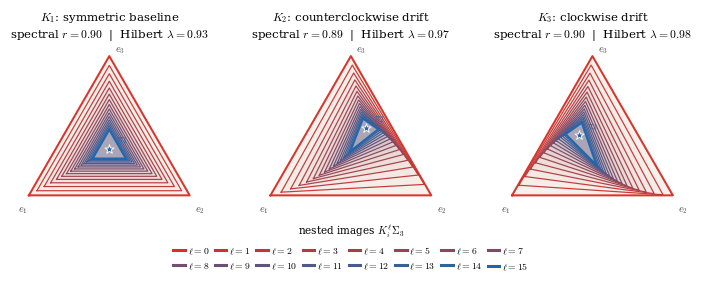

In [4]:
def draw_kernel_contraction(
    ax: plt.Axes,
    item: dict,
    kernel_index: int,
    max_power: int,
) -> None:
    """Draw nested images of the simplex for one Markov kernel.

    Args:
        ax: Matplotlib axes receiving the simplex geometry.
        item: Kernel, stationary law, and contraction diagnostics.
        kernel_index: One-based kernel label used in the panel title.
        max_power: Largest displayed iteration exponent.

    Returns:
        None. The axes are modified in place.
    """
    ax.fill(
        SIMPLEX_VERTICES[:, 0],
        SIMPLEX_VERTICES[:, 1],
        color="#f7f5f0",
        zorder=0,
    )

    for power in range(max_power + 1):
        triangle = simplex_image(item["kernel"], power)
        closed = np.vstack([triangle, triangle[0]])
        color = interp_color(power / max_power)
        ax.fill(
            triangle[:, 0],
            triangle[:, 1],
            color=color,
            alpha=0.018 + 0.040 * power / max_power,
            zorder=1 + power,
        )
        ax.plot(
            closed[:, 0],
            closed[:, 1],
            color=color,
            lw=1.45 if power in (0, max_power) else 0.86,
            alpha=0.97,
            solid_joinstyle="round",
            zorder=10 + power,
        )

    stationary_xy = barycentric_to_plane(item["stationary"])
    ax.scatter(
        [stationary_xy[0]],
        [stationary_xy[1]],
        marker="*",
        s=48,
        color=BLUE,
        edgecolor="white",
        linewidth=0.65,
        zorder=30,
    )
    ax.annotate(
        rf"$\pi_{kernel_index}$",
        stationary_xy,
        xytext=(5, 5),
        textcoords="offset points",
        color=BLUE,
        fontsize=7.8,
        fontweight="bold",
        zorder=31,
    )

    vertex_offsets = [(-8, -12), (4, -12), (4, 3)]
    for vertex_index, (vertex, offset) in enumerate(
        zip(SIMPLEX_VERTICES, vertex_offsets),
        start=1,
    ):
        ax.annotate(
            rf"$e_{vertex_index}$",
            vertex,
            xytext=offset,
            textcoords="offset points",
            color=GRAY,
            fontsize=7.3,
        )

    ax.set_title(
        rf"$K_{kernel_index}$: {item['description']}"
        + "\n"
        + rf"spectral $r={item['spectral_rate']:.2f}$"
        + rf"  |  Hilbert $\lambda={item['contraction']:.2f}$",
        fontsize=8.45,
        pad=1.5,
    )
    ax.set_aspect("equal")
    ax.set_xlim(-0.09, 1.09)
    ax.set_ylim(-0.14, 0.95)
    remove_axes(ax)


def render_figure(max_power: int = MAX_POWER) -> plt.Figure:
    """Render and export the three Birkhoff simplex-contraction panels.

    Args:
        max_power: Largest exponent ell displayed in K^ell Sigma_3.

    Returns:
        Matplotlib figure containing the three nested-simplex diagrams.
    """
    figure, axes = plt.subplots(1, 3, figsize=(7.25, 2.85))
    for index, (ax, item) in enumerate(zip(axes, KERNELS), start=1):
        draw_kernel_contraction(ax, item, index, max_power)

    colors = [interp_color(power / max_power) for power in range(max_power + 1)]
    handles = [Line2D([0], [0], color=color, lw=2.2) for color in colors]
    labels = [rf"$\ell={power}$" for power in range(max_power + 1)]
    legend_columns = min(8, max_power + 1)
    legend_rows = int(np.ceil((max_power + 1) / legend_columns))
    legend_order = [
        column + row * legend_columns
        for column in range(legend_columns)
        for row in range(legend_rows)
        if column + row * legend_columns <= max_power
    ]
    handles = [handles[index] for index in legend_order]
    labels = [labels[index] for index in legend_order]
    figure.legend(
        handles,
        labels,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.004),
        ncol=legend_columns,
        frameon=False,
        handlelength=1.18,
        handletextpad=0.28,
        columnspacing=0.60,
        fontsize=7.0,
        title=r"nested images $K_i^\ell\Sigma_3$",
        title_fontsize=7.5,
    )
    figure.subplots_adjust(
        left=0.018,
        right=0.982,
        bottom=0.225,
        top=0.84,
        wspace=0.12,
    )

    save_pdf(figure, OUT / "simplex-contraction.pdf", pad_inches=0.035)
    THUMBNAIL.parent.mkdir(parents=True, exist_ok=True)
    figure.savefig(
        THUMBNAIL,
        dpi=220,
        bbox_inches="tight",
        pad_inches=0.04,
        facecolor="white",
    )
    return figure


FIGURE = render_figure()
plt.show()

## Figure preview

The exported thumbnail below is generated from the same vector figure used by the manuscript.

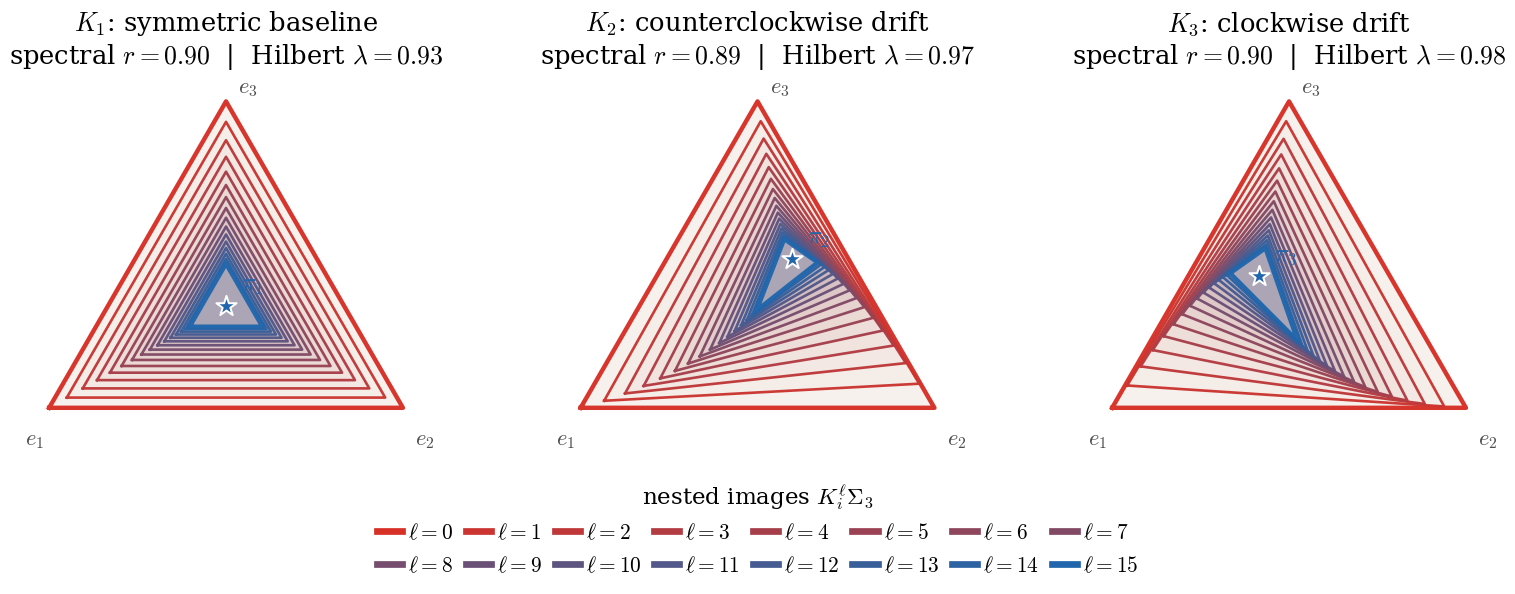

In [5]:
from IPython.display import Image, display

display(Image(filename=str(THUMBNAIL)))
